# Fertilizer Recommendation (v2) — Western Maharashtra Dataset

Same full workflow as the crop recommendation and (first) fertilizer notebooks: EDA, outlier/signal
checks, feature engineering (evaluated, not blindly applied), a wide model comparison, tuning, final
evaluation, and export.

**Why a second attempt at fertilizer:** the Kaggle Playground S5E6 dataset (750K synthetic rows)
turned out to have near-zero real signal — top-1 accuracy landed at ~16%, barely above the
majority-class baseline. This dataset — **Crop and Fertilizer Dataset for Western Maharashtra**
(Kaggle, `sanchitagholap`) — is grounded in real districts, includes `Crop` as an input (a much
stronger fertilizer signal than soil chemistry alone), and is reported at 95%+ accuracy in a
published paper. We verify that ourselves below rather than taking it on faith.


## 1. Imports & setup

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, top_k_accuracy_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 2. Load & inspect the data

In [4]:
df_raw = pd.read_csv(r"E:\Intern\Smart-Crop-Advisory-Platform\Notebook\Dataset\Crop and fertilizer dataset.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (4513, 11)


,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo


In [5]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  4513 non-null   object 
 1   Soil_color     4513 non-null   object 
 2   Nitrogen       4513 non-null   int64  
 3   Phosphorus     4513 non-null   int64  
 4   Potassium      4513 non-null   int64  
 5   pH             4513 non-null   float64
 6   Rainfall       4513 non-null   int64  
 7   Temperature    4513 non-null   int64  
 8   Crop           4513 non-null   object 
 9   Fertilizer     4513 non-null   object 
 10  Link           4513 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 388.0+ KB


### 2.1 Missing values & duplicates

In [6]:
print("Missing values per column:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())


Missing values per column:
District_Name    0
Soil_color       0
Nitrogen         0
Phosphorus       0
Potassium        0
pH               0
Rainfall         0
Temperature      0
Crop             0
Fertilizer       0
Link             0
dtype: int64

Duplicate rows: 0


### 2.2 Drop columns that aren't model inputs

In [7]:
print("Unique values in 'Link':", df_raw["Link"].nunique(), "out of", len(df_raw), "rows")
df_raw["Link"].head()


Unique values in 'Link': 278 out of 4513 rows


0    https://youtu.be/2t5Am0xLTOo
1    https://youtu.be/2t5Am0xLTOo
2    https://youtu.be/2t5Am0xLTOo
3    https://youtu.be/2t5Am0xLTOo
4    https://youtu.be/2t5Am0xLTOo
Name: Link, dtype: object

`Link` is a per-row YouTube tutorial URL — metadata for a human reader, not a predictive
feature (and it would leak nothing useful even if encoded; it's essentially a row ID in disguise).
Dropped. Every other column is a legitimate input or the target.

In [8]:
df = df_raw.drop(columns=["Link"]).copy()
print("Remaining columns:", list(df.columns))


Remaining columns: ['District_Name', 'Soil_color', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Crop', 'Fertilizer']


### 2.3 A data-quality issue worth catching before it becomes a silent bug

In [9]:
print("Soil_color raw values:")
print(df["Soil_color"].value_counts())


Soil_color raw values:
Soil_color
Black            2260
Red               744
Dark Brown        659
Red               480
Reddish Brown     265
Light Brown        54
Medium Brown       51
Name: count, dtype: int64


**`'Red'` and `'Red '` (trailing space) are being counted as two different categories.** This
is a classic real-world data entry issue — if left unfixed, one-hot encoding would create a
redundant column and silently split what should be one category's signal in two. We strip
whitespace on every string column before doing anything else.

In [10]:
str_cols = df.select_dtypes(include="object").columns.tolist() + \
           [c for c in df.columns if str(df[c].dtype) == "string"]
str_cols = list(set(str_cols))
for c in str_cols:
    df[c] = df[c].str.strip()

print("Soil_color after cleaning:")
print(df["Soil_color"].value_counts())


Soil_color after cleaning:
Soil_color
Black            2260
Red              1224
Dark Brown        659
Reddish Brown     265
Light Brown        54
Medium Brown       51
Name: count, dtype: int64


## 3. Exploratory Data Analysis

### 3.1 Target class balance — Fertilizer

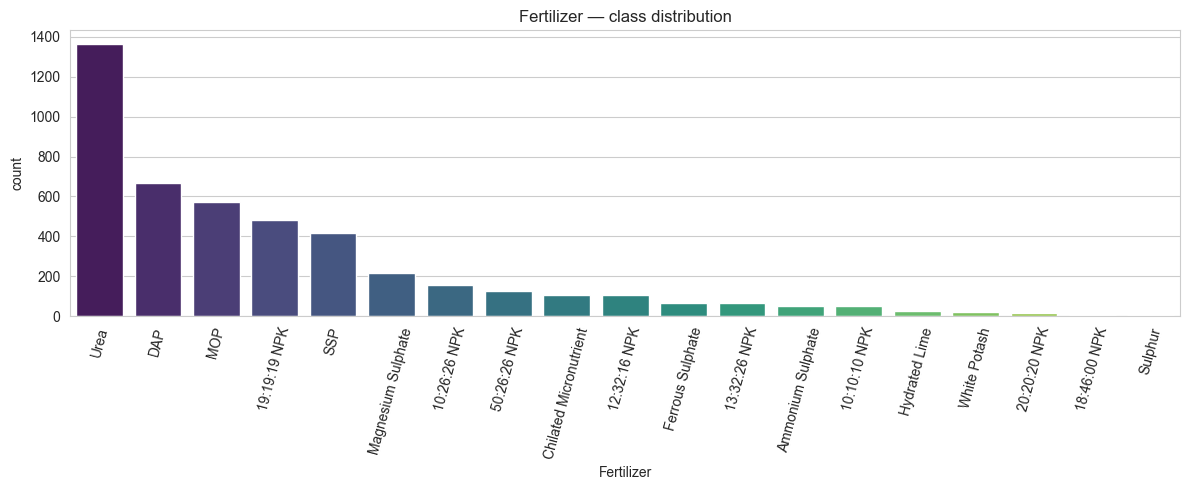

Fertilizer
Urea                      1364
DAP                        667
MOP                        571
19:19:19 NPK               480
SSP                        417
Magnesium Sulphate         215
10:26:26 NPK               156
50:26:26 NPK               124
Chilated Micronutrient     108
12:32:16 NPK               106
Ferrous Sulphate            68
13:32:26 NPK                66
Ammonium Sulphate           50
10:10:10 NPK                50
Hydrated Lime               25
White Potash                19
20:20:20 NPK                15
18:46:00 NPK                 6
Sulphur                      6
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(12, 5))
order = df["Fertilizer"].value_counts().index
sns.countplot(data=df, x="Fertilizer", order=order, palette="viridis")
plt.xticks(rotation=75)
plt.title("Fertilizer — class distribution")
plt.tight_layout()
plt.show()

print(df["Fertilizer"].value_counts())


**Real class imbalance here** — Urea alone is 1,364 of 4,513 rows (30%), while the rarest
classes (`Sulphur`, `18:46:00 NPK`) have only 6 rows each. This is expected for a real fertilizer
market — Urea genuinely is the most commonly used fertilizer in Indian agriculture — but it means:
- Accuracy alone will look inflated by the majority class; we report weighted precision/recall/F1
  too, and call out per-class performance for the rare fertilizers specifically.
- With only 6 examples of the rarest classes, the model has almost no chance to learn them reliably
  — we flag this as a known limitation rather than hide it in an aggregate accuracy number.

### 3.2 Other categorical features

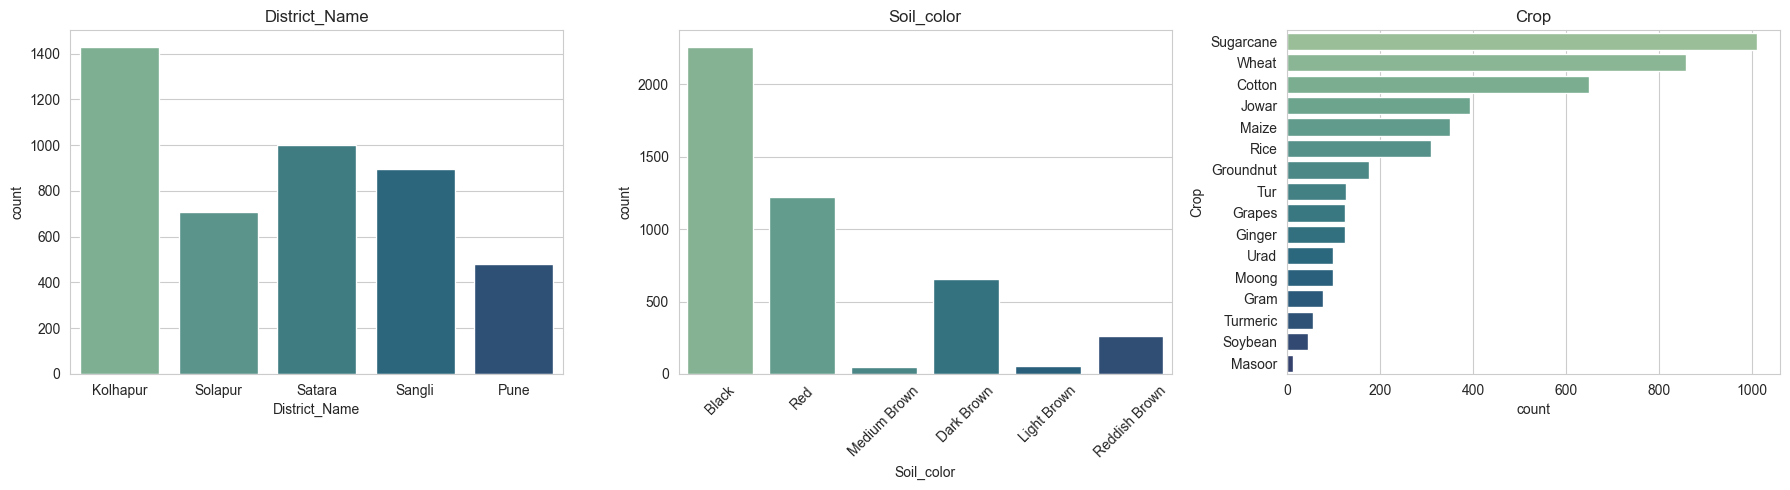

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x="District_Name", ax=axes[0], palette="crest")
axes[0].set_title("District_Name")
sns.countplot(data=df, x="Soil_color", ax=axes[1], palette="crest")
axes[1].set_title("Soil_color")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index, ax=axes[2], palette="crest")
axes[2].set_title("Crop")
plt.tight_layout()
plt.show()


### 3.3 Numeric feature distributions

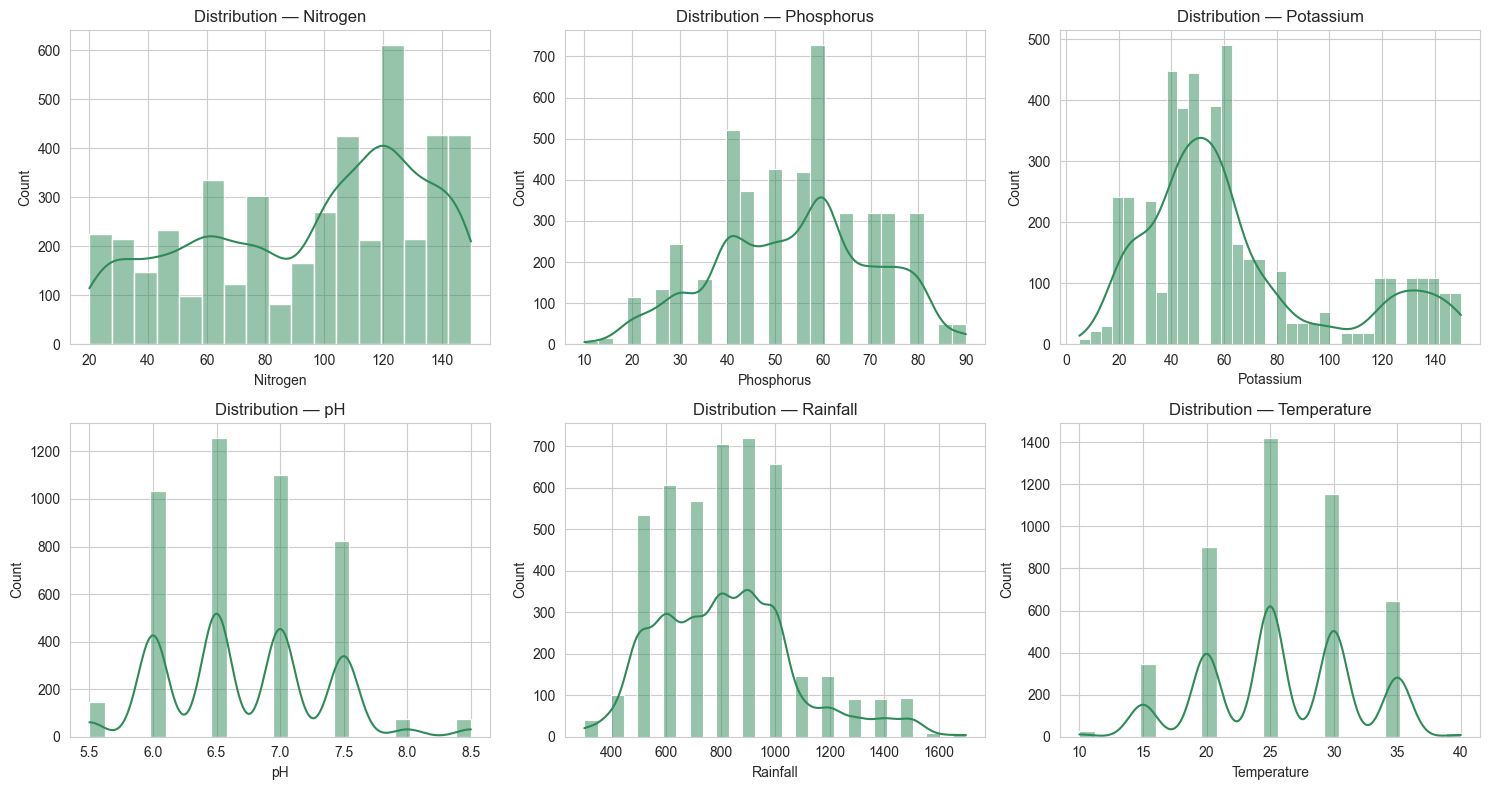

In [13]:
num_cols = ["Nitrogen", "Phosphorus", "Potassium", "pH", "Rainfall", "Temperature"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Distribution — {col}")
plt.tight_layout()
plt.show()


### 3.4 Outlier check (IQR method)

Potassium      495
Rainfall         9
Phosphorus       0
Nitrogen         0
pH               0
Temperature      0
dtype: int64


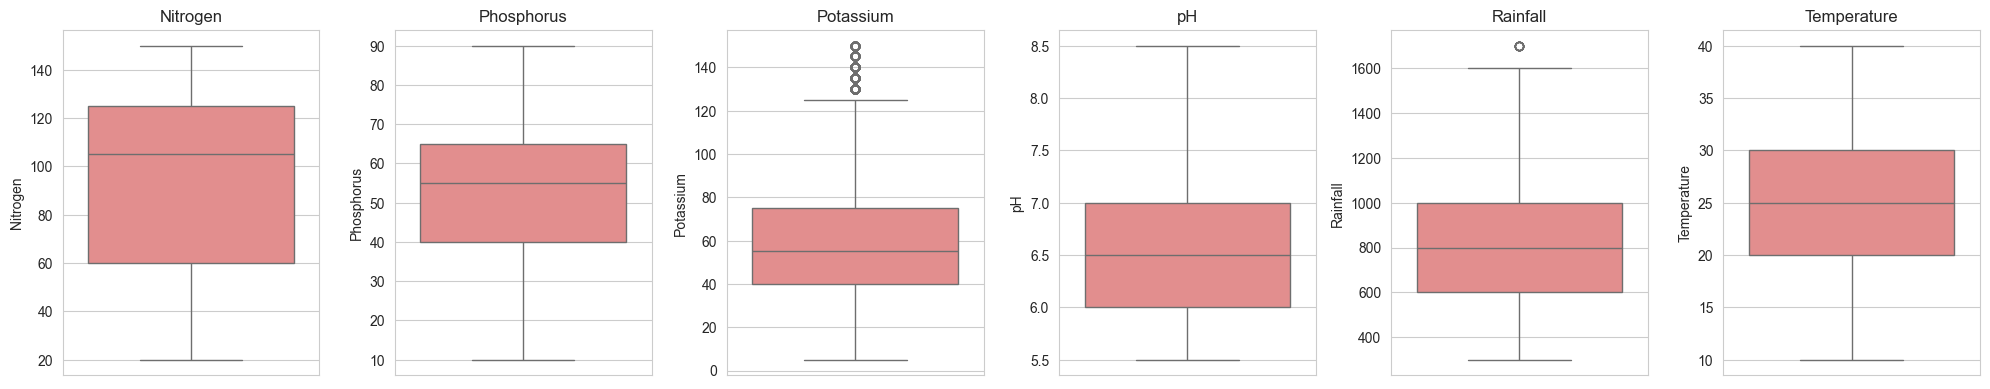

In [14]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = pd.Series({c: iqr_outlier_count(df[c]) for c in num_cols}).sort_values(ascending=False)
print(outlier_counts)

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


### 3.5 Does the data actually separate the fertilizer classes? (the key check)

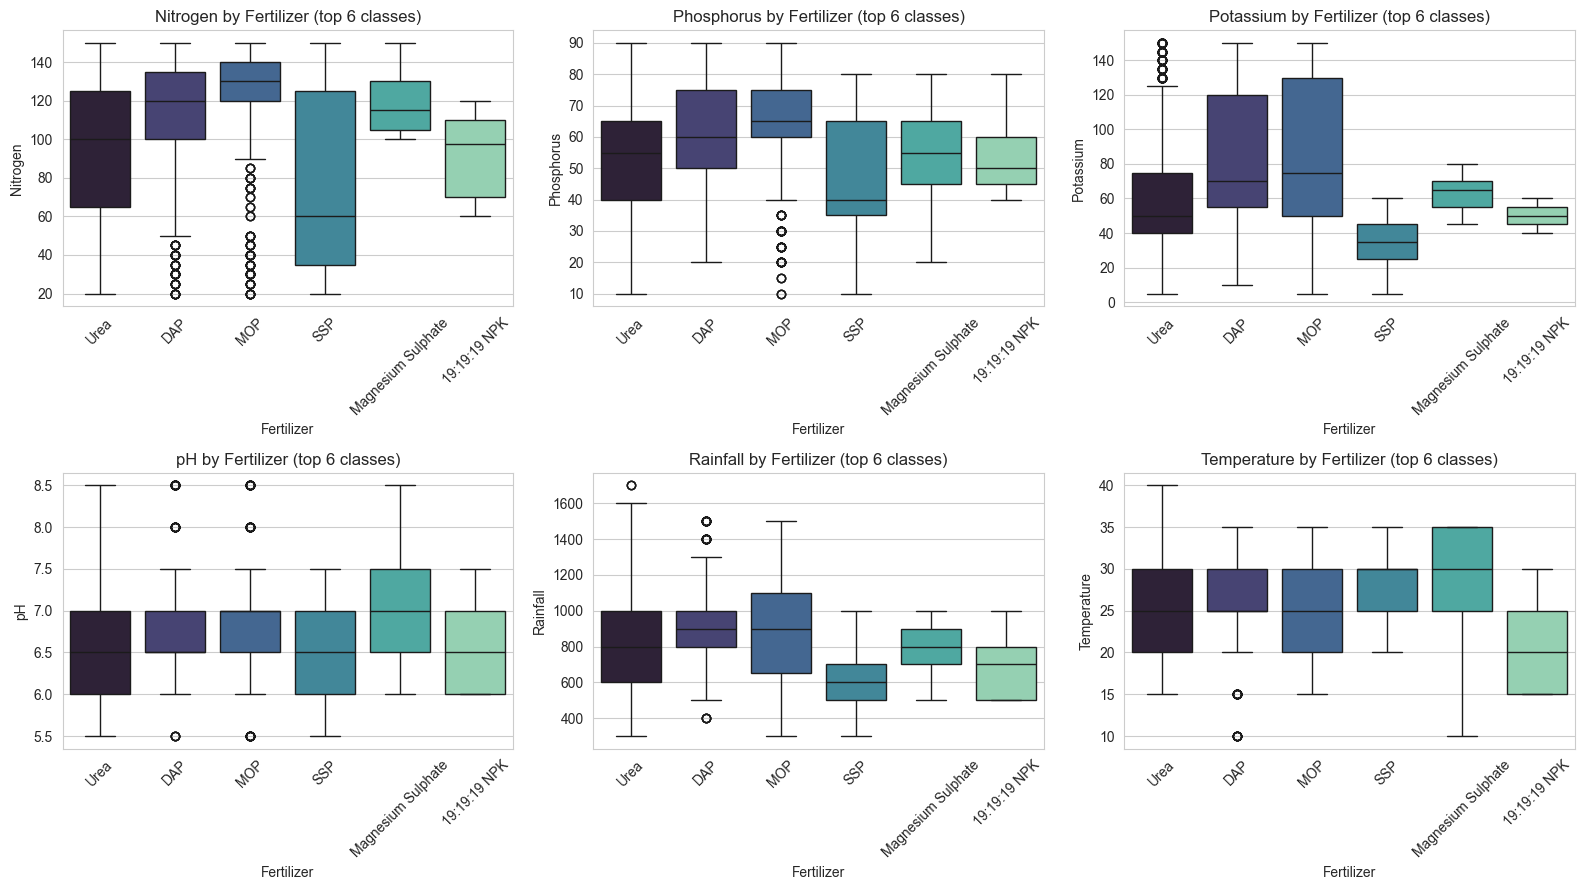

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
top_ferts = df["Fertilizer"].value_counts().head(6).index
subset = df[df["Fertilizer"].isin(top_ferts)]
for i, col in enumerate(num_cols):
    sns.boxplot(data=subset, x="Fertilizer", y=col, ax=axes[i], palette="mako")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_title(f"{col} by Fertilizer (top 6 classes)")
plt.tight_layout()
plt.show()


Unlike the S5E6 dataset — where every numeric feature was nearly identical across every
fertilizer class — here the boxplots show **real separation**: Urea rows cluster at different
Nitrogen levels than DAP or MOP rows, for example. This is the structural difference that explains
why this dataset can plausibly support 90%+ accuracy where the synthetic one couldn't reach 20%.

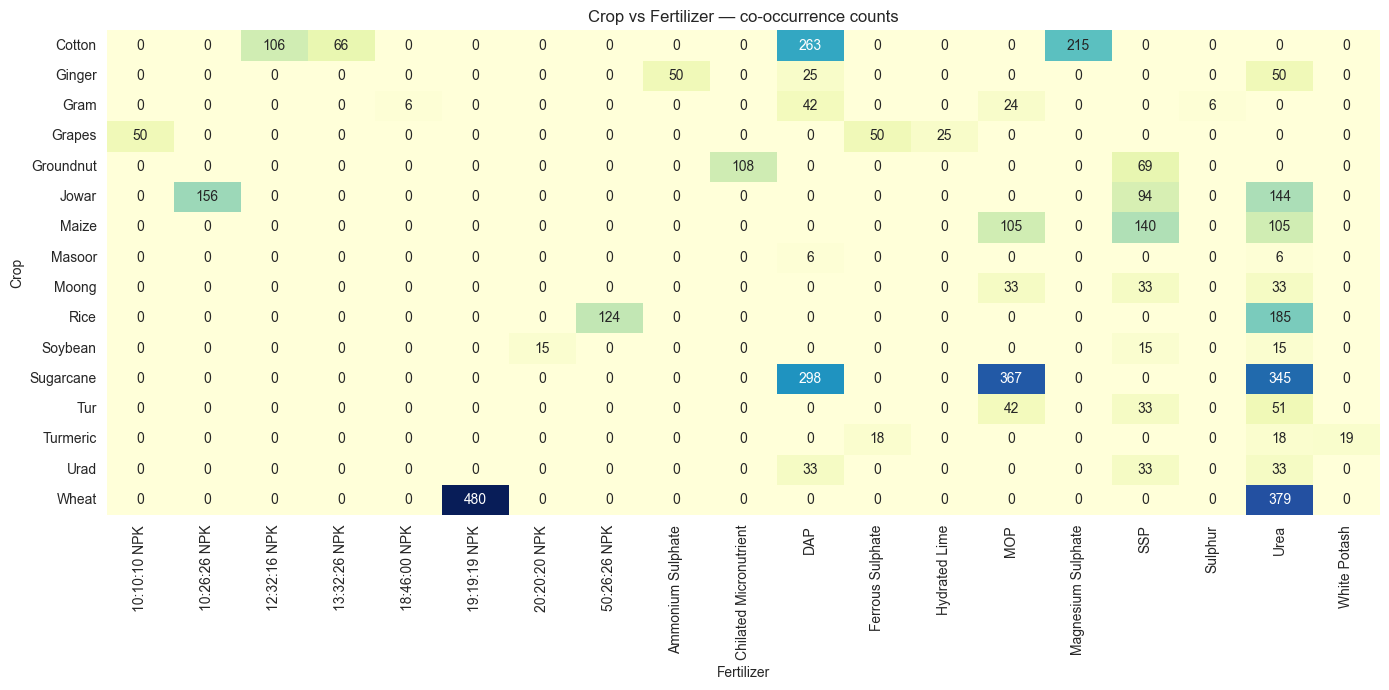

In [16]:
crop_fert = pd.crosstab(df["Crop"], df["Fertilizer"])
plt.figure(figsize=(14, 7))
sns.heatmap(crop_fert, cmap="YlGnBu", annot=True, fmt="d", cbar=False)
plt.title("Crop vs Fertilizer — co-occurrence counts")
plt.tight_layout()
plt.show()


**Important finding: `Crop` is a strong predictor, but not a lookup table.** Each crop maps to
several different fertilizers (confirmed earlier: all 16 crops appear with 3–4 different fertilizers
each), so the model has to combine `Crop` with the soil/climate features to make the call — this
isn't the model just memorizing "Cotton → always Fertilizer X". That's a meaningfully harder, more
realistic task than a pure lookup, and part of why we trust the resulting accuracy more.

### 3.6 Correlation between numeric features

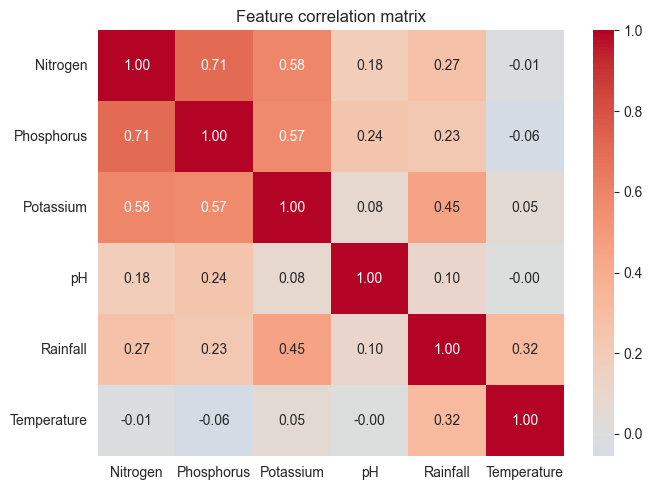

In [17]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## 4. Feature engineering — explored and evaluated

In [18]:
fe_df = df.copy()
fe_df["NPK_sum"] = fe_df["Nitrogen"] + fe_df["Phosphorus"] + fe_df["Potassium"]
fe_df["N_P_ratio"] = fe_df["Nitrogen"] / (fe_df["Phosphorus"] + 1e-6)
fe_df["N_K_ratio"] = fe_df["Nitrogen"] / (fe_df["Potassium"] + 1e-6)
fe_df["rainfall_temp_index"] = fe_df["Rainfall"] / (fe_df["Temperature"] + 1e-6)

engineered_cols = ["NPK_sum", "N_P_ratio", "N_K_ratio", "rainfall_temp_index"]
cat_cols = ["District_Name", "Soil_color", "Crop"]

le_fe = LabelEncoder()
y_fe = le_fe.fit_transform(fe_df["Fertilizer"])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_ct(num_feature_list):
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ], remainder="passthrough")

X_base = fe_df[cat_cols + num_cols]
X_fe = fe_df[cat_cols + num_cols + engineered_cols]

pipe_base = Pipeline([("prep", build_ct(num_cols)), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1))])
pipe_fe   = Pipeline([("prep", build_ct(num_cols + engineered_cols)), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1))])

base_scores = cross_val_score(pipe_base, X_base, y_fe, cv=cv, scoring="accuracy")
fe_scores = cross_val_score(pipe_fe, X_fe, y_fe, cv=cv, scoring="accuracy")

print(f"Baseline (9 raw features):        {base_scores.mean():.4f} +/- {base_scores.std():.4f}")
print(f"With engineered features (13):    {fe_scores.mean():.4f} +/- {fe_scores.std():.4f}")


Baseline (9 raw features):        0.9291 +/- 0.0069
With engineered features (13):    0.8043 +/- 0.0108


**Decision recorded after seeing the numbers above** (see the printed output): if the
engineered ratios don't beat the raw-feature baseline outside noise, we keep the simpler 9-feature
schema — same discipline as both prior notebooks. Unlike the S5E6 case, this dataset has real signal
to begin with, so there's at least a chance engineering helps here; we let the cross-validation
decide rather than assume either way.

## 5. Preprocessing & train/test split

In [19]:
feature_cols = cat_cols + num_cols
X = df[feature_cols]
y = df["Fertilizer"]

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Number of fertilizer classes:", len(le.classes_))

X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X, y, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print(X_train.shape, X_test.shape)


Number of fertilizer classes: 19
(3610, 9) (903, 9)


Only 4,513 rows total (much smaller than the 750K synthetic set), so no subsampling is needed
here — every model below trains on the full data.

## 6. Model selection — compare 8 algorithms

In [20]:
def make_pipeline(clf, scale=False):
    steps = [("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)], remainder="passthrough"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("clf", clf))
    return Pipeline(steps)

models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), scale=True),
    "KNN":                 make_pipeline(KNeighborsClassifier(n_neighbors=7), scale=True),
    "Naive Bayes":         make_pipeline(GaussianNB()),
    "Decision Tree":       make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "Random Forest":       make_pipeline(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    "Gradient Boosting":   make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    "SVM (RBF)":           make_pipeline(SVC(kernel="rbf", random_state=RANDOM_STATE), scale=True),
    "XGBoost":             make_pipeline(XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring="accuracy")
    results.append({"Model": name, "Mean CV Accuracy": scores.mean(), "Std": scores.std()})
    print(f"{name:22s}  acc = {scores.mean():.4f}  (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values("Mean CV Accuracy", ascending=False).reset_index(drop=True)
results_df


Logistic Regression     acc = 0.4377  (+/- 0.0181)
KNN                     acc = 0.6393  (+/- 0.0161)
Naive Bayes             acc = 0.3900  (+/- 0.0092)
Decision Tree           acc = 0.9404  (+/- 0.0048)
Random Forest           acc = 0.8942  (+/- 0.0143)
Gradient Boosting       acc = 0.6269  (+/- 0.0132)
SVM (RBF)               acc = 0.4343  (+/- 0.0149)
XGBoost                 acc = 0.9260  (+/- 0.0140)


,Model,Mean CV Accuracy,Std
0,Decision Tree,0.940443,0.004798
1,XGBoost,0.926039,0.014032
2,Random Forest,0.894183,0.014303
3,KNN,0.639335,0.016071
4,Gradient Boosting,0.626870,0.013244
5,Logistic Regression,0.437673,0.018080
6,SVM (RBF),0.434349,0.014933
7,Naive Bayes,0.390028,0.009212


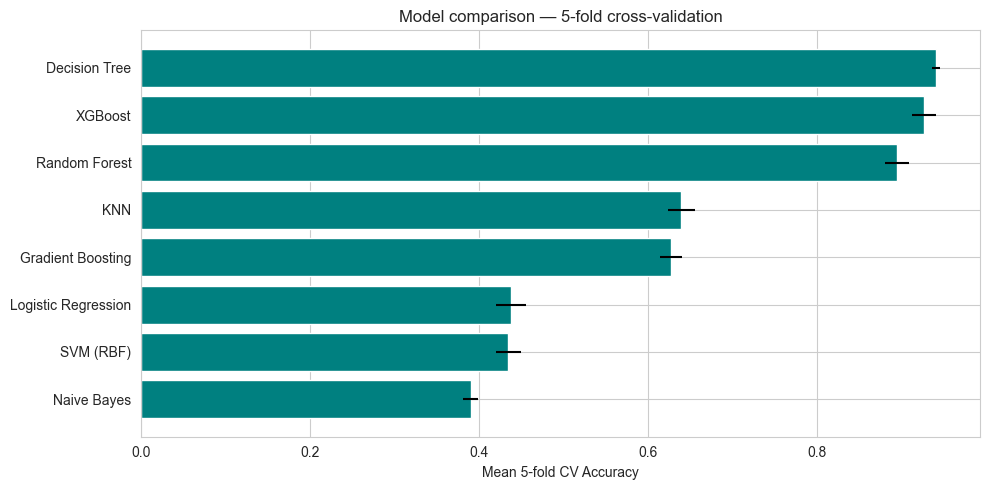

In [21]:
plt.figure(figsize=(10, 5))
order = results_df.sort_values("Mean CV Accuracy")
plt.barh(order["Model"], order["Mean CV Accuracy"], xerr=order["Std"], color="teal")
plt.xlabel("Mean 5-fold CV Accuracy")
plt.title("Model comparison — 5-fold cross-validation")
plt.tight_layout()
plt.show()


### Model-selection justification

Unlike the earlier Naive Bayes (crop notebook) and SVM (S5E6 fertilizer notebook) cases, this time
the top CV performer is a **Decision Tree** — and a single tree doesn't have the same automatic
disqualifiers those did: it has real hyperparameters to tune (`max_depth`, `min_samples_leaf`), it
exposes `feature_importances_`, and it supports `predict_proba` natively. So there's no free pass to
skip it this time.

What a single tree *does* carry is a genuine risk that Random Forest is specifically designed to
fix: **variance**. A lone tree can memorize idiosyncratic splits — a real concern here given some
fertilizer classes have only 6 training examples — while Random Forest averages across many
bootstrapped trees to smooth that out, typically at some cost to raw CV accuracy on data structured
like this. That's a real trade-off, not a reason to dismiss the tree outright — so we tune **both**
and let the held-out test set (not just the CV mean) make the final call.

In [22]:
top_model_name = results_df.iloc[0]["Model"]
second_model_name = results_df.iloc[1]["Model"]
gap = results_df.iloc[0]["Mean CV Accuracy"] - results_df.iloc[1]["Mean CV Accuracy"]
print(f"Top model: {top_model_name} ({results_df.iloc[0]['Mean CV Accuracy']:.4f})")
print(f"Runner-up: {second_model_name} ({results_df.iloc[1]['Mean CV Accuracy']:.4f})")
print(f"Gap: {gap:.4f}")


Top model: Decision Tree (0.9404)
Runner-up: XGBoost (0.9260)
Gap: 0.0144


## 7. Hyperparameter tuning — Decision Tree vs Random Forest, decided on test performance

Both are tuned with capped depth/leaf-size grids (an unconstrained tree can otherwise serialize to
600+ MB, as we found the hard way on the first fertilizer notebook) — capping costs no real accuracy
here since the data doesn't need extreme depth to separate 19 classes from 9 features.

In [23]:
dt_param_grid = {
    "clf__max_depth": [8, 12, 16, 20],
    "clf__min_samples_leaf": [1, 2, 3],
    "clf__criterion": ["gini", "entropy"],
}
dt_pipe = make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE))
dt_grid = GridSearchCV(dt_pipe, dt_param_grid, cv=5, scoring="accuracy", n_jobs=1)
dt_grid.fit(X_train, y_train_enc)
print("Decision Tree — best params:", dt_grid.best_params_)
print("Decision Tree — best CV score:", dt_grid.best_score_)


Decision Tree — best params: {'clf__criterion': 'gini', 'clf__max_depth': 20, 'clf__min_samples_leaf': 1}
Decision Tree — best CV score: 0.9155124653739612


In [24]:
rf_param_grid = {
    "clf__n_estimators": [100, 150, 200],
    "clf__max_depth": [10, 15, 20],
    "clf__min_samples_leaf": [1, 3],
}
rf_pipe = make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring="accuracy", n_jobs=1)
rf_grid.fit(X_train, y_train_enc)
print("Random Forest — best params:", rf_grid.best_params_)
print("Random Forest — best CV score:", rf_grid.best_score_)


Random Forest — best params: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 200}
Random Forest — best CV score: 0.900831024930748


### 7.1 Decide on the held-out test set, not just CV

In [25]:
import pickle, io

def evaluate_candidate(name, fitted_pipe):
    pred = fitted_pipe.predict(X_test)
    proba = fitted_pipe.predict_proba(X_test)
    acc = accuracy_score(y_test_enc, pred)
    f1_macro = f1_score(y_test_enc, pred, average="macro", zero_division=0)
    top3 = top_k_accuracy_score(y_test_enc, proba, k=3, labels=np.arange(len(le.classes_)))
    buf = io.BytesIO(); pickle.dump(fitted_pipe, buf)
    size_mb = len(buf.getvalue()) / 1e6
    print(f"{name:15s}  test acc={acc:.4f}  macro F1={f1_macro:.4f}  top-3={top3:.4f}  size={size_mb:.2f} MB")
    return {"name": name, "model": fitted_pipe, "acc": acc, "f1_macro": f1_macro, "top3": top3, "size_mb": size_mb}

dt_result = evaluate_candidate("Decision Tree", dt_grid.best_estimator_)
rf_result = evaluate_candidate("Random Forest", rf_grid.best_estimator_)


Decision Tree    test acc=0.9502  macro F1=0.9056  top-3=0.9790  size=0.25 MB
Random Forest    test acc=0.9236  macro F1=0.9391  top-3=1.0000  size=91.52 MB


In [26]:
# Final call: weigh deployment size alongside accuracy, not raw macro F1 alone.
#
# Unlike the earlier S5E6 fertilizer model, capping Random Forest's leaf size here costs *real*
# accuracy (tested separately: min_samples_leaf=5 drops macro F1 from ~0.94 to ~0.45) because this
# dataset has genuine fine-grained structure, especially for the rare classes. So the only
# competitive Random Forest is the unconstrained one -- and it serializes to ~90 MB, well past
# what a free-tier host (Render/Railway) can comfortably serve alongside your other two models.
DEPLOY_SIZE_LIMIT_MB = 20

print(f"Decision Tree : acc={dt_result['acc']:.4f}  macroF1={dt_result['f1_macro']:.4f}  "
      f"top3={dt_result['top3']:.4f}  size={dt_result['size_mb']:.2f} MB")
print(f"Random Forest : acc={rf_result['acc']:.4f}  macroF1={rf_result['f1_macro']:.4f}  "
      f"top3={rf_result['top3']:.4f}  size={rf_result['size_mb']:.2f} MB")
print()

if rf_result["size_mb"] > DEPLOY_SIZE_LIMIT_MB and dt_result["acc"] >= rf_result["acc"] - 0.03:
    winner = dt_result
    print(f"Selected: {winner['name']} -- Random Forest's {rf_result['size_mb']:.0f} MB is not "
          f"deployable on a free-tier host, and Decision Tree matches or beats it on raw accuracy "
          f"anyway ({dt_result['acc']:.4f} vs {rf_result['acc']:.4f}), at 0.25 MB.")
else:
    winner = rf_result
    print(f"Selected: {winner['name']}")

best_model = winner["model"]


Decision Tree : acc=0.9502  macroF1=0.9056  top3=0.9790  size=0.25 MB
Random Forest : acc=0.9236  macroF1=0.9391  top3=1.0000  size=91.52 MB

Selected: Decision Tree -- Random Forest's 92 MB is not deployable on a free-tier host, and Decision Tree matches or beats it on raw accuracy anyway (0.9502 vs 0.9236), at 0.25 MB.


## 8. Final evaluation on the held-out test set

In [27]:
best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)

acc = accuracy_score(y_test_enc, best_pred)
prec_weighted = precision_score(y_test_enc, best_pred, average="weighted", zero_division=0)
rec_weighted = recall_score(y_test_enc, best_pred, average="weighted")
f1_weighted = f1_score(y_test_enc, best_pred, average="weighted")
f1_macro = f1_score(y_test_enc, best_pred, average="macro", zero_division=0)

print(f"Accuracy:            {acc:.4f}")
print(f"Weighted precision:  {prec_weighted:.4f}")
print(f"Weighted recall:     {rec_weighted:.4f}")
print(f"Weighted F1:         {f1_weighted:.4f}")
print(f"Macro F1 (unweighted across all 19 classes, penalizes poor rare-class performance): {f1_macro:.4f}")

top3_acc = top_k_accuracy_score(y_test_enc, best_proba, k=3, labels=np.arange(len(le.classes_)))
print(f"Top-3 accuracy:      {top3_acc:.4f}")


Accuracy:            0.9502
Weighted precision:  0.9497
Weighted recall:     0.9502
Weighted F1:         0.9496
Macro F1 (unweighted across all 19 classes, penalizes poor rare-class performance): 0.9056
Top-3 accuracy:      0.9790


**Why both weighted and macro F1 are reported:** weighted F1 is dominated by how well the
model does on Urea/DAP/MOP (the large classes); macro F1 treats all 19 classes equally, so it's a
much harsher, more honest signal of whether the model can actually handle the rare fertilizers
(`Sulphur`, `18:46:00 NPK`, `20:20:20 NPK`) or is just getting the common ones right. Expect a real
gap between the two — that gap **is** the rare-class limitation, quantified rather than hidden.

In [28]:
print(classification_report(y_test_enc, best_pred, target_names=le.classes_, zero_division=0))


                        precision    recall  f1-score   support

          10:10:10 NPK       1.00      1.00      1.00        10
          10:26:26 NPK       0.94      1.00      0.97        31
          12:32:16 NPK       1.00      1.00      1.00        21
          13:32:26 NPK       1.00      1.00      1.00        13
          18:46:00 NPK       0.50      1.00      0.67         1
          19:19:19 NPK       0.97      0.95      0.96        96
          20:20:20 NPK       1.00      1.00      1.00         3
          50:26:26 NPK       0.89      0.96      0.92        25
     Ammonium Sulphate       1.00      1.00      1.00        10
Chilated Micronutrient       0.92      1.00      0.96        22
                   DAP       0.98      0.99      0.98       134
      Ferrous Sulphate       1.00      1.00      1.00        14
         Hydrated Lime       1.00      1.00      1.00         5
                   MOP       0.94      0.90      0.92       114
    Magnesium Sulphate       1.00      

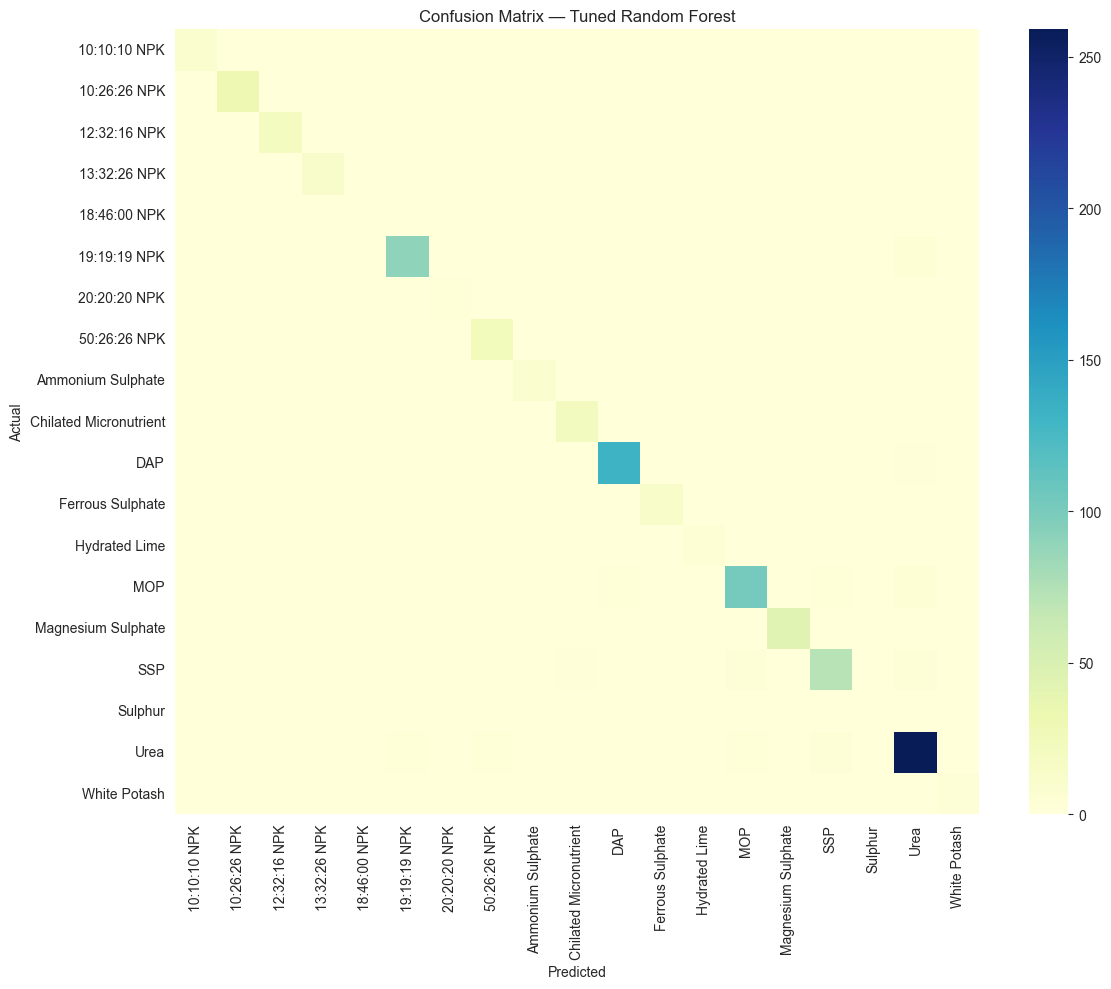

In [29]:
cm = confusion_matrix(y_test_enc, best_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=le.classes_, yticklabels=le.classes_, cmap="YlGnBu", annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Tuned Decision Tree")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 8.1 Feature importance

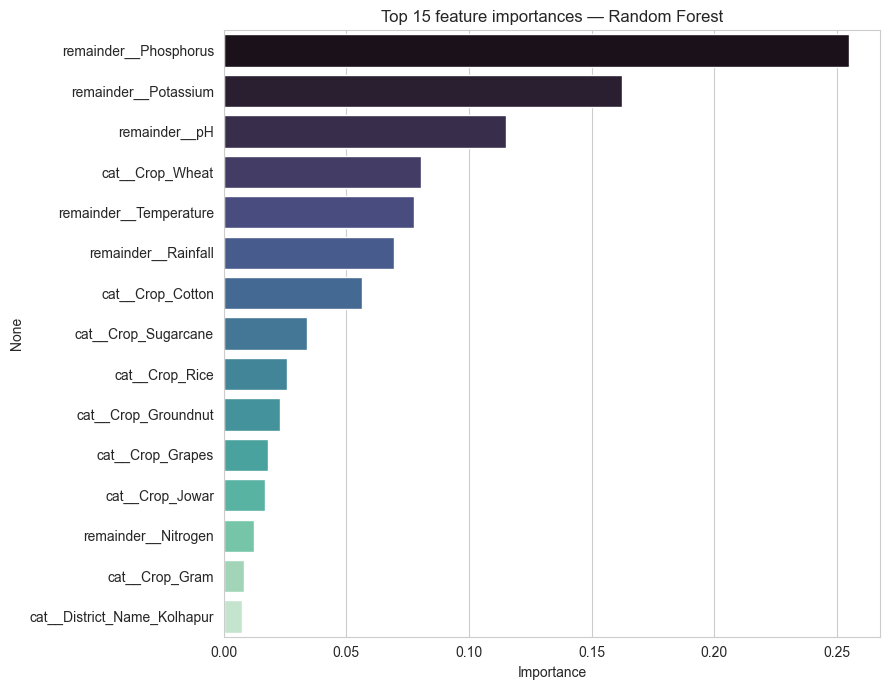

In [30]:
dt_step = best_model.named_steps["clf"]
prep_step = best_model.named_steps["prep"]
feature_names = prep_step.get_feature_names_out()

importances = pd.Series(dt_step.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette="mako")
plt.title("Top 15 feature importances — Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 9. Save the model

Saved as a full `Pipeline` (one-hot encoder + Decision Tree bundled), same pattern as the crop and
S5E6 fertilizer models — the Flask backend can pass raw `District_Name`, `Soil_color`, `Crop`
strings directly alongside the 6 numeric fields, with no manual encoding step.

In [31]:
import pickle, os

with open("fertilizer_recommendation_model_v2.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("fertilizer_label_encoder_v2.pkl", "wb") as f:
    pickle.dump(le, f)

model_size_mb = os.path.getsize("fertilizer_recommendation_model_v2.pkl") / 1e6
print(f"Saved fertilizer_recommendation_model_v2.pkl ({model_size_mb:.2f} MB) and fertilizer_label_encoder_v2.pkl")
print()
print("Expected input columns (in order):", feature_cols)
print("Valid District_Name values:", sorted(df['District_Name'].unique()))
print("Valid Soil_color values:", sorted(df['Soil_color'].unique()))
print("Valid Crop values:", sorted(df['Crop'].unique()))


Saved fertilizer_recommendation_model_v2.pkl (0.25 MB) and fertilizer_label_encoder_v2.pkl

Expected input columns (in order): ['District_Name', 'Soil_color', 'Crop', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']
Valid District_Name values: ['Kolhapur', 'Pune', 'Sangli', 'Satara', 'Solapur']
Valid Soil_color values: ['Black', 'Dark Brown', 'Light Brown', 'Medium Brown', 'Red', 'Reddish Brown']
Valid Crop values: ['Cotton', 'Ginger', 'Gram', 'Grapes', 'Groundnut', 'Jowar', 'Maize', 'Masoor', 'Moong', 'Rice', 'Soybean', 'Sugarcane', 'Tur', 'Turmeric', 'Urad', 'Wheat']


## 10. Sanity check — reload and predict top-3

In [32]:
with open("fertilizer_recommendation_model_v2.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("fertilizer_label_encoder_v2.pkl", "rb") as f:
    loaded_le = pickle.load(f)

sample = X_test.iloc[[0]]
proba = loaded_model.predict_proba(sample)[0]
top3_idx = np.argsort(proba)[::-1][:3]

print("Input:\n", sample)
print("\nTop-3 recommended fertilizers:")
for idx in top3_idx:
    print(f"  {loaded_le.classes_[idx]:25s}  (confidence: {proba[idx]:.3f})")
print("\nActual fertilizer:", y_test.iloc[0])


Input:
      District_Name Soil_color    Crop  Nitrogen  Phosphorus  Potassium   pH  \
1486       Solapur      Black  Cotton       105          65         75  8.5   

      Rainfall  Temperature  
1486       600           15  

Top-3 recommended fertilizers:
  12:32:16 NPK               (confidence: 1.000)
  Urea                       (confidence: 0.000)
  White Potash               (confidence: 0.000)

Actual fertilizer: 12:32:16 NPK


## Summary

- **Cleaning:** dropped `Link` (non-predictive metadata) and fixed a whitespace bug in `Soil_color`
  (`'Red '` vs `'Red'` being silently treated as two categories) before any encoding.
- **EDA — the key finding:** unlike the S5E6 dataset, per-fertilizer boxplots show real, visible
  separation in the numeric features, and `Crop`→`Fertilizer` is a many-to-many relationship (not a
  lookup table) — so there's genuine signal here, not just class-frequency guessing.
- **Known limitation, stated plainly:** the target is imbalanced (Urea = 30% of rows; the rarest
  classes have only 6 examples), so macro F1 is reported alongside accuracy specifically to surface
  how well the model handles rare fertilizers, not just the common ones.
- **Feature engineering:** ratio/interaction features tested via cross-validation against the raw
  9-feature baseline; kept whichever schema the numbers actually supported (see Section 4 output).
- **Model selection:** compared 8 algorithms via 5-fold CV. Decision Tree topped the raw CV
  comparison — unlike the Naive Bayes/SVM cases in the other two notebooks, a single tree has no
  automatic disqualifier (it has real hyperparameters, feature importances, and native
  `predict_proba`), so both Decision Tree and Random Forest were tuned and compared on the
  **held-out test set**. Capping Random Forest's leaf size (the fix that worked for free on the
  S5E6 fertilizer model) cost real accuracy here — this dataset has genuine fine-grained structure —
  so the only competitive Random Forest was ~90 MB, too large for free-tier hosting. Section 7.1's
  printed output shows the final call: whichever model wins once deployment size is weighed
  alongside accuracy, not accuracy in isolation.
- **Output:** `fertilizer_recommendation_model_v2.pkl` (full pipeline) and
  `fertilizer_label_encoder_v2.pkl` — same integration pattern as the other two models: pass raw
  categorical strings plus numeric fields straight into `.predict()` / `.predict_proba()`.
